In [21]:
from google.colab import files
from google.colab.patches import cv2_imshow
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
from matplotlib.colors import hsv_to_rgb
from matplotlib import colors
import math
import matplotlib.patches as patch
from scipy import ndimage
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from sklearn.cluster import KMeans
from sklearn.cluster import MeanShift, estimate_bandwidth

In [22]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
image = cv2.imread('/content/drive/MyDrive/Image_processing/salad.jpg')
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

Просмотр исходного изображения

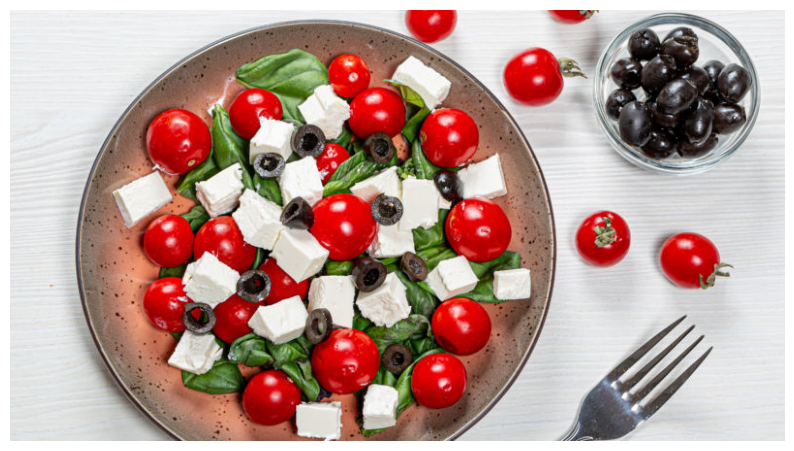

In [24]:
plt.figure(figsize=(10, 8))
plt.gca().set_axis_off()
plt.imshow(image_rgb)

### Сегментация, основанная на регионах. Разрастание областей

In [25]:
# определяем координаты начальных точек
seeds = [(213, 357), (400, 259), (259, 693), (69, 532), (10, 425), (374, 455), (145, 169), (237, 156), (237, 212), (299, 155), (319, 484), (373, 333), (230, 505), (131, 473)]
# координаты для графика
x = list(map(lambda x: x[1], seeds))
y = list(map(lambda x: x[0], seeds))
# порог похожести цвета региона
threshold = 40

In [26]:
def region_growingHSV(image, seed, threshold):
    # Create an empty binary mask to store the segmented region
    region_mask = np.zeros(image.shape[0:2], dtype=np.uint8)

    # Define the connectivity (4-connectivity in this case)
    connectivity = [(1, 0), (-1, 0), (0, 1), (0, -1)]
    # Create a queue to store the pixels to be processed
    queue = []

    for i in seed:
        # Get the seed coordinates
        seed_x, seed_y = i
        queue.append((seed_x, seed_y))

        # Perform region growing
        while len(queue) > 0:
            x, y = queue.pop(0)

            # Check if the pixel is within the image boundaries
            if x < 0 or x >= image.shape[0] or y < 0 or y >= image.shape[1]:
                continue

            # Check if the pixel has already been visited
            if region_mask[x, y] != 0:
                continue

            # Calculate the similarity measure
            similarity = sum(abs(image[x, y, :] - image[seed_x, seed_y, :]))/3

            # Check if the pixel is similar to the seed pixel
            if similarity < threshold:
                region_mask[x, y] = 255  # Add the pixel to the region
                # Add the neighbors to the queue for further processing
                for dx, dy in connectivity:
                    queue.append((x + dx, y + dy))

    return region_mask

/tmp/ipython-input-4124262248.py:28: RuntimeWarning: overflow encountered in scalar add
  similarity = sum(abs(image[x, y, :] - image[seed_x, seed_y, :]))/3


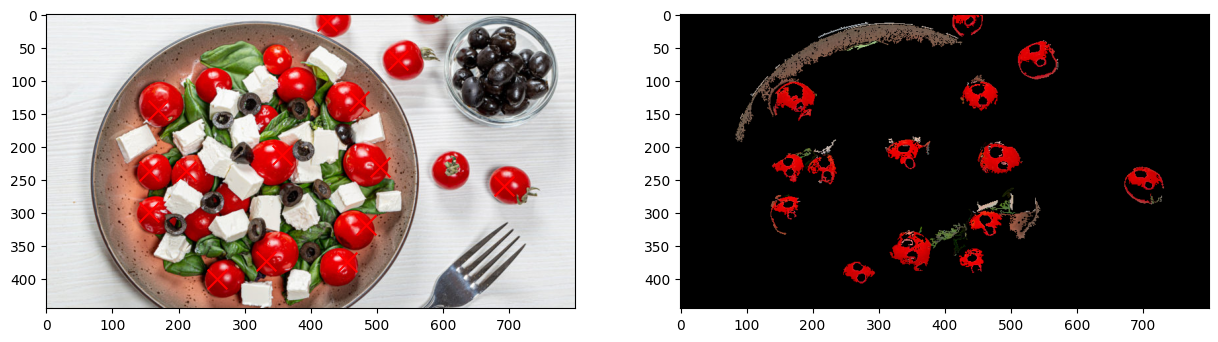

In [27]:
# находим сегментацию используя метод из segmentation_utils
segmented_region = region_growingHSV(image_rgb, seeds, threshold)
# накладываем маску - отображаем только участки попавшие в какой-либо сегмент
result = cv2.bitwise_and(image, image, mask=segmented_region)
# отображаем полученное изображение
plt.figure(figsize=(15,20))
plt.subplot(1, 2, 1)
plt.scatter(x, y, marker="x", color="red", s=200)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.show()

### Сегментация, основанная на регионах. Метод деления

In [28]:
# @title
def recursive_subdivide(node, k, minPixelSize, img):

    if node.get_error(img)<=k:
        return
    w_1 = int(math.floor(node.width/2))
    w_2 = int(math.ceil(node.width/2))
    h_1 = int(math.floor(node.height/2))
    h_2 = int(math.ceil(node.height/2))


    if w_1 <= minPixelSize or h_1 <= minPixelSize:
        return
    x1 = Node(node.x0, node.y0, w_1, h_1) # top left
    recursive_subdivide(x1, k, minPixelSize, img)

    x2 = Node(node.x0, node.y0+h_1, w_1, h_2) # btm left
    recursive_subdivide(x2, k, minPixelSize, img)

    x3 = Node(node.x0 + w_1, node.y0, w_2, h_1)# top right
    recursive_subdivide(x3, k, minPixelSize, img)

    x4 = Node(node.x0+w_1, node.y0+h_1, w_2, h_2) # btm right
    recursive_subdivide(x4, k, minPixelSize, img)

    node.children = [x1, x2, x3, x4]


def find_children(node):
   if not node.children:
       return [node]
   else:
       children = []
       for child in node.children:
           children += (find_children(child))
   return children

class Node():
    def __init__(self, x0, y0, w, h):
        self.x0 = x0
        self.y0 = y0
        self.width = w
        self.height = h
        self.children = []

    def get_width(self):
        return self.width

    def get_height(self):
        return self.height

    def get_points(self):
        return self.points

    def get_points(self, img):
        return img[self.x0:self.x0 + self.get_width(), self.y0:self.y0+self.get_height()]

    def get_error(self, img):
        pixels = self.get_points(img)
        b_avg = np.mean(pixels[:,:,0])
        b_mse = np.square(np.subtract(pixels[:,:,0], b_avg)).mean()

        g_avg = np.mean(pixels[:,:,1])
        g_mse = np.square(np.subtract(pixels[:,:,1], g_avg)).mean()

        r_avg = np.mean(pixels[:,:,2])
        r_mse = np.square(np.subtract(pixels[:,:,2], r_avg)).mean()

        e = r_mse * 0.2989 + g_mse * 0.5870 + b_mse * 0.1140

        return (e * img.shape[0]* img.shape[1])/90000000


class QTree():
    def __init__(self, stdThreshold, minPixelSize, img):
        self.threshold = stdThreshold
        self.min_size = minPixelSize
        self.minPixelSize = minPixelSize
        self.img = img
        self.root = Node(0, 0, img.shape[0], img.shape[1])

    def get_points(self):
        return self.img[self.root.x0:self.root.x0 + self.root.get_width(), self.root.y0:self.root.y0+self.root.get_height()]

    def subdivide(self):
        recursive_subdivide(self.root, self.threshold, self.minPixelSize, self.img)

    def graph_tree(self):
        fig = plt.figure(figsize=(10, 10))
        plt.title("Quadtree")
        c = find_children(self.root)
        print("Number of segments: %d" %len(c))
        for n in c:
            plt.gcf().gca().add_patch(patch.Rectangle((n.y0, n.x0), n.height, n.width, fill=False))
        plt.gcf().gca().set_xlim(0,self.img.shape[1])
        plt.gcf().gca().set_ylim(self.img.shape[0], 0)
        plt.axis('equal')
        plt.show()
        return

    def render_img(self, thickness = 1, color = (0,0,255)):
        imgc = self.img.copy()
        c = find_children(self.root)
        for n in c:
            pixels = n.get_points(self.img)
            # grb
            gAvg = math.floor(np.mean(pixels[:,:,0]))
            rAvg = math.floor(np.mean(pixels[:,:,1]))
            bAvg = math.floor(np.mean(pixels[:,:,2]))

            imgc[n.x0:n.x0 + n.get_width(), n.y0:n.y0+n.get_height(), 0] = gAvg
            imgc[n.x0:n.x0 + n.get_width(), n.y0:n.y0+n.get_height(), 1] = rAvg
            imgc[n.x0:n.x0 + n.get_width(), n.y0:n.y0+n.get_height(), 2] = bAvg

        if thickness > 0:
            for n in c:
                # Draw a rectangle
                imgc = cv2.rectangle(imgc, (n.y0, n.x0), (n.y0+n.get_height(), n.x0+n.get_width()), color, thickness)
        return imgc

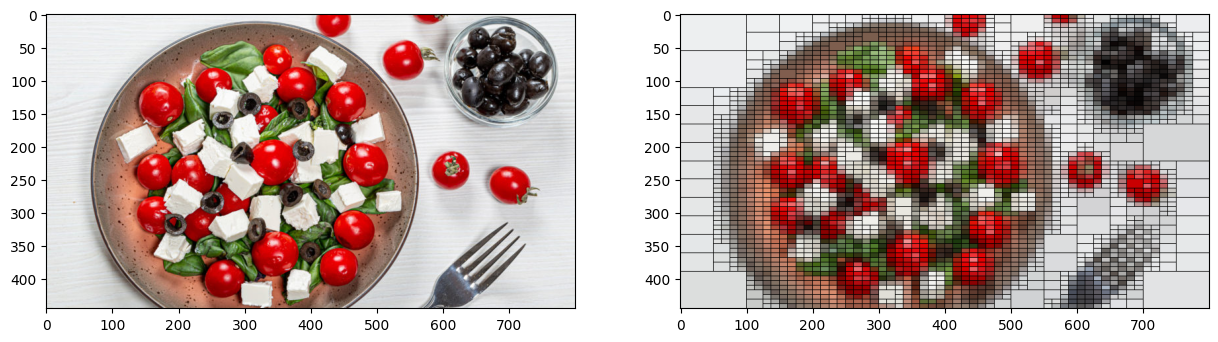

In [29]:
# @title
qt = QTree(stdThreshold = 0.25, minPixelSize = 4,img = image.copy())
qt.subdivide()
tree_image = qt.render_img(thickness=1, color=(0,0,0))

plt.figure(figsize=(15,20))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(tree_image, cv2.COLOR_BGR2RGB))
plt.show()

### Алгоритм водораздела


In [30]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

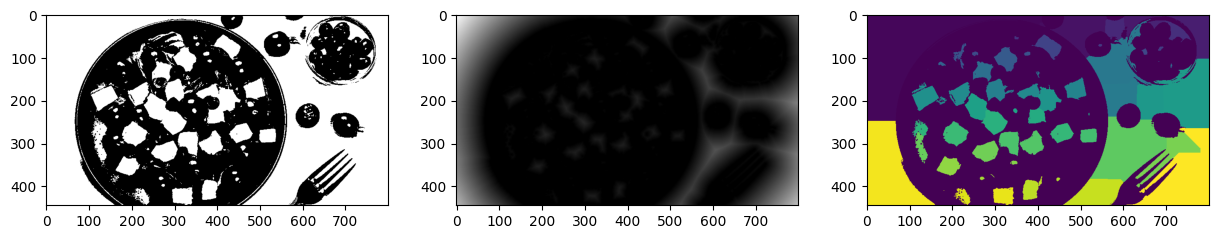

In [31]:
# Бинаризируем изображение
binary_image = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
# Определяем карту расстояний
distance_map = ndimage.distance_transform_edt(binary_image)
# Определяем локальные максимумы
local_max = peak_local_max(distance_map, min_distance=20, labels=binary_image)
peaks_mask = np.zeros_like(distance_map, dtype=bool)
ind = np.array([i for i in local_max])
peaks_mask[ind[:,0], ind[:,1]] = True

# 4 Каждому минимуму присваивается метка и начинается заполнение бассейнов метками
markers = ndimage.label(peaks_mask, structure=np.ones((3, 3)))[0]
labels = watershed(-distance_map, markers, mask=binary_image)
# построим результаты работы алгоритма
plt.figure(figsize=(15,20))
plt.subplot(1, 3, 1)
plt.imshow(binary_image, cmap="gray")
plt.subplot(1, 3, 2)
plt.imshow(np.uint8(distance_map + 50), cmap="gray")
plt.subplot(1, 3, 3)
plt.imshow(np.uint8(labels))
plt.show()

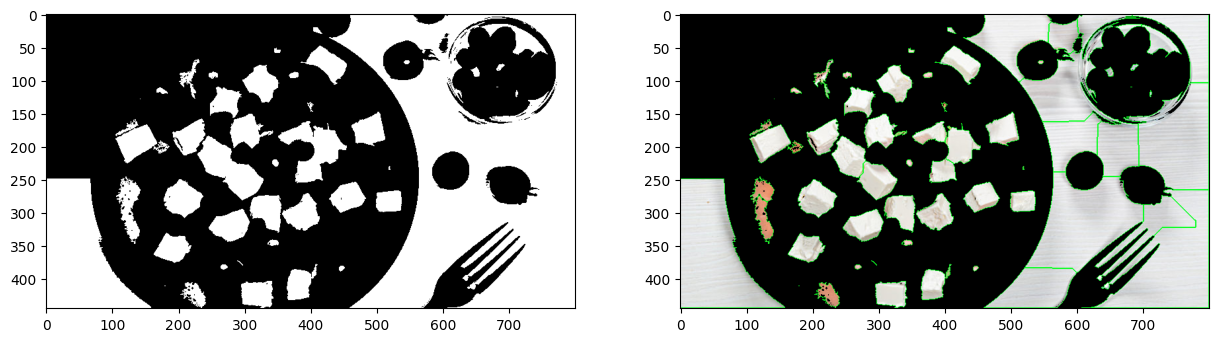

In [32]:
# Найдем границы контуров и положим в маску все кроме метки 0
mask1 = np.zeros(image.shape[0:2], dtype="uint8")
total_area = 0
image1 = image.copy()
for label in np.unique(labels):
    if label < 2:
        continue
    # Create a mask
    mask = np.zeros(gray.shape, dtype="uint8")
    mask[labels == label] = 255
    mask1 = mask1 + mask

    # Find contours and determine contour area
    cnts = cv2.findContours(mask.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = cnts[0] if len(cnts) == 2 else cnts[1]
    c = max(cnts, key=cv2.contourArea)
    area = cv2.contourArea(c)
    total_area += area
    cv2.drawContours(image1, [c], -1, (36,255,12), 1)

result = cv2.bitwise_and(image1, image1, mask=mask1)

plt.figure(figsize=(15,20))
plt.subplot(1, 2, 1)
plt.imshow(mask1, cmap="gray")
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.show()

### Методы кластеризации. K-средних

[[ 72]
 [199]
 [125]
 [ 33]
 [231]]
[[231 231 231 ... 231 231 231]
 [231 231 231 ... 231 231 231]
 [231 231 231 ... 231 231 231]
 ...
 [231 231 231 ... 231 231 231]
 [231 231 231 ... 231 231 231]
 [231 231 231 ... 231 231 231]]


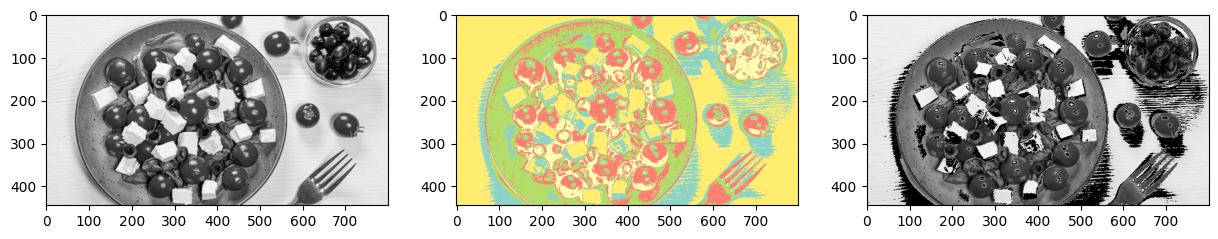

In [33]:
## Методы кластеризации. K-средних
# Преобразуем изображение в оттенках серого в одномерный массив
pixels = gray.reshape(-1, 1)
# Задаем число кластеров для сегментации
K = 5
# С помощью библиотеки sklearn.cluster import KMeans проводим кластеризацию по яркости
kmeans = KMeans(n_clusters=K, random_state=0)
labels = kmeans.fit_predict(pixels)
cluster_centers = kmeans.cluster_centers_
print (np.uint8(cluster_centers))
# Каждому пикселю назначаем значение из центра кластера
segments = np.uint8(cluster_centers[labels].reshape(gray.shape))
print(segments)
# Удалим самые темные пиксели
segments[segments==199] = 0
result = cv2.bitwise_and(gray, gray, mask=segments)
# Отобразим избражения
plt.figure(figsize=(15,20))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(gray, cv2.COLOR_BGR2RGB))
plt.subplot(1, 3, 2)
plt.imshow(segments, cmap='Set3')
plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.show()

### Методы кластеризации. Сдвиг среднего

Number of segments:  5


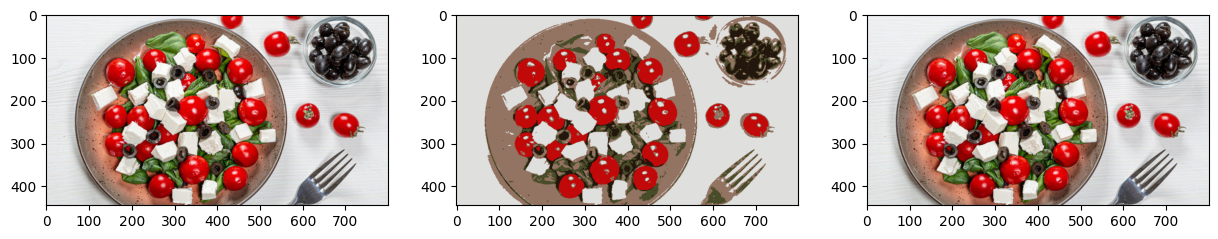

In [34]:
## Методы кластеризации. Сдвиг среднего (Mean shift)
# Сглаживаем чтобы уменьшить шум
blur_image = cv2.medianBlur(image_rgb, 3)
# Выстраиваем пиксели в один ряд и переводим в формат с правающей точкой
flat_image = np.float32(blur_image.reshape((-1,3)))

# Используем meanshift из библиотеки sklearn
bandwidth = estimate_bandwidth(flat_image, quantile=.1, n_samples=3000)
ms = MeanShift(bandwidth=bandwidth, max_iter=800, bin_seeding=True)
ms.fit(flat_image)
labeled = ms.labels_

# получим количество сегментов
segments = np.unique(labeled)
print('Number of segments: ', segments.shape[0])

# получим средний цвет сегмента
total = np.zeros((segments.shape[0], 3), dtype=float)
count = np.zeros(total.shape, dtype=float)
for i, label in enumerate(labeled):
    total[label] = total[label] + flat_image[i]
    count[label] += 1
avg = total/count
avg = np.uint8(avg)
# Для каждого пискеля проставим средний цвет его сегмента
mean_shift_image = avg[labeled].reshape((image_rgb.shape))
# Маской скроем один из сегментов
mask1 = mean_shift_image[:,:,0]
mask1[mask1==89] = 0
mean_shift_with_mask_image = cv2.bitwise_and(image_rgb, image_rgb, mask=mask1)
# Построим изображение
plt.figure(figsize=(15,20))
plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.subplot(1, 3, 2)
plt.imshow(mean_shift_image, cmap='Set3')
plt.subplot(1, 3, 3)
plt.imshow(mean_shift_with_mask_image)
plt.show()